# Re-Implementing a GPT-2 Style Decoder from Scratch

### Minimal Transformer Language Model Implementation using PyTorch

This project recreates the core architecture of a GPT-2 style decoder-only transformer using PyTorch.  
The goal is to understand the internal mechanics of modern language models by implementing the architecture components manually rather than relying on high-level frameworks.

The model is trained on a small text dataset to demonstrate **autoregressive language modeling and text generation**.

Key concepts explored in this project:

• Transformer Decoder Architecture  
• Self-Attention Mechanism  
• Token Embeddings  
• Positional Encoding  
• Autoregressive Text Generation  
• Language Modeling with PyTorch

## Environment Setup and Dependencies

The following libraries are used for building and training the transformer model:

- **PyTorch** for deep learning and tensor operations  
- **tiktoken** for GPT-style tokenization  
- **DataLoader utilities** for efficient dataset batching

These libraries enable efficient implementation of transformer architectures and language modeling pipelines.

In [1]:
import torch 
import torch.nn as nn
import torch
import tiktoken
import torch
from torch.utils.data import DataLoader,Dataset

## GPT-2 Tokenizer Initialization

Before training the model, raw text must be converted into numerical tokens.

We use the **GPT-2 tokenizer from the `tiktoken` library**, which maps text into integer token IDs compatible with GPT-style vocabularies.

Tokenization enables the model to process language in a numerical format while preserving semantic structure.

In [2]:
tokenizer = tiktoken.get_encoding('gpt2')

## Loading the Training Dataset

The training corpus is loaded from a local text file.  
This dataset provides the raw language data used to train the autoregressive language model.

Steps performed:

1. Read raw text from file
2. Store the text for preprocessing
3. Prepare it for tokenization and dataset creation

In [3]:
import os
import requests

file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

## Model Configuration

A configuration dictionary is defined to store the architectural parameters of the GPT model.

Important parameters include:

- **Vocabulary Size** – total number of tokens in the tokenizer
- **Context Length** – maximum sequence length the model can process
- **Embedding Dimension** – dimensionality of token embeddings
- **Number of Transformer Layers**
- **Number of Attention Heads**

These parameters define the structure and capacity of the transformer model.

In [4]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

## Core Transformer Components

This section implements key building blocks used in a GPT-style Transformer decoder.

**GELU Activation** – A smooth non-linear activation function commonly used in transformer models.

**Feed Forward Network (FFN)** – A two-layer fully connected network that expands the embedding dimension and projects it back, enabling richer feature learning.

**Layer Normalization** – Normalizes token representations to stabilize training and improve convergence.

**Multi-Head Self Attention** – The core mechanism that allows each token to attend to other tokens in the sequence using Query, Key, and Value projections.

A **causal mask** is applied to ensure tokens only attend to previous tokens, preserving the autoregressive nature of language modeling.

In [5]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

    
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec

## Transformer Decoder Block

This module implements a single **Transformer block**, the core unit of GPT-style architectures.

Each block contains:

- **Masked Multi-Head Self Attention** to capture contextual relationships between tokens  
- **Feed Forward Network (FFN)** to transform token representations  
- **Layer Normalization** for training stability  
- **Residual Connections (Skip Connections)** to preserve information and improve gradient flow  
- **Dropout** for regularization

Multiple transformer blocks are stacked together to build the full GPT decoder model.

In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.feed_forward = FeedForward(cfg)
        self.norm_1 = LayerNorm(cfg["emb_dim"])
        self.norm_2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm_1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm_2(x)
        x = self.feed_forward(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

## GPT Decoder Model

This class defines the full **GPT-style decoder architecture**.

Main components:

- **Token Embeddings** – convert token IDs into dense vector representations  
- **Positional Embeddings** – encode token order in the sequence  
- **Stacked Transformer Blocks** – capture contextual relationships using self-attention  
- **Final Layer Normalization** – stabilizes the output representation  
- **Output Projection Layer** – maps hidden states to vocabulary logits for next-token prediction

The model follows an **autoregressive language modeling approach**, predicting the next token based on previous tokens in the sequence.

In [7]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


## Text Generation Utilities

These helper functions support the **autoregressive text generation process**.

- **generate_simple_text()** – generates new tokens iteratively by predicting the next token from the model output.  
- **text_to_token_ids()** – converts raw text into token IDs using the tokenizer.  
- **token_ids_to_text()** – converts generated token IDs back into readable text.

This pipeline enables the model to take an input prompt and produce generated text sequences.

In [8]:
def generate_simple_text(model,idx,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[: ,-1, :]
        probas = torch.softmax(logits,dim=-1)
        idx_next = torch.argmax(probas,dim=-1,keepdim=True)
        idx = torch.cat((idx,idx_next),dim=1)
        
    return idx

def text_to_token_ids(text,tokenizer):
    encoded = tokenizer.encode(text,allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids,tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

## Train–Validation Split

The dataset is divided into **training** and **validation** sets.

- **Training set (90%)** is used to learn model parameters.  
- **Validation set (10%)** is used to evaluate model performance during training.

This separation helps monitor how well the model generalizes to unseen data.

In [9]:
train_ratio = 0.90
split_index = int(train_ratio * len(text_data))
train_data = text_data[:split_index]
val_data = text_data[split_index:]

print(len(train_data))
print(len(val_data))

18431
2048


## Custom Dataset and DataLoader

This section defines a custom **PyTorch Dataset** for preparing training samples.

- The text is first tokenized using the GPT-2 tokenizer.  
- Input sequences are created using a **sliding window approach**.  
- Each input sequence has a corresponding **target sequence shifted by one token**, enabling next-token prediction.

A **DataLoader** is then used to efficiently create batches for training the language model.

In [10]:
class GPTDatasetV1(Dataset):
    def __init__(self,txt,tokenizer,max_length,stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, index):
        return self.input_ids[index],self.target_ids[index]


def dataloaderv1(txt,max_length = 256,stride = 128,batch_size = 4,num_workers = 0,drop_last = True,shuffle = True):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt,tokenizer,max_length,stride)
    dataloader = DataLoader(dataset,batch_size,shuffle=shuffle,num_workers=num_workers,drop_last=drop_last)

    return dataloader


## Training and Validation DataLoaders

DataLoaders are created for both the training and validation datasets.

- **Training Loader** – provides shuffled batches to help the model learn generalized patterns.
- **Validation Loader** – evaluates model performance on unseen data.

The batch size, context length, and stride are aligned with the model configuration to ensure consistent input sequence lengths during training.

In [11]:
torch.manual_seed(123)

train_loader = dataloaderv1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = dataloaderv1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

## Loss Computation

This section defines helper functions to compute the **training loss** for the language model.

- **cal_loss_batch()** computes the cross-entropy loss for a single batch by comparing predicted logits with the target tokens.
- **calc_loss_loader()** calculates the average loss over multiple batches from a DataLoader.

Cross-entropy loss is used because the task is **next-token prediction in a language modeling setting**.

In [12]:
def cal_loss_batch(input_batch,target_batch,model,device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1),target_batch.flatten())
    return loss

def calc_loss_loader(data_loader,model,device,num_batches=0):
    total_loss = 0
    if len(data_loader) is None:
        return float("nan")
    elif num_batches == 0:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches,len(data_loader))

    for i,(input_batch,target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = cal_loss_batch(input_batch,target_batch,model,device)
            total_loss += loss
        else:
            break
    return total_loss/num_batches

## Training and Evaluation Pipeline

This section implements the core training workflow for the GPT model.

- **evaluate_model()** computes training and validation loss to monitor model performance.  
- **generate_and_print_sample()** generates sample text during training to observe learning progress.  
- **train_model_simple()** performs the training loop including forward pass, backpropagation, optimization, and periodic evaluation.

This pipeline enables iterative model training while tracking performance and generated outputs.

In [13]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model,tokenizer,device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context,tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_simple_text(model,encoded,max_new_tokens=50,context_size=context_size)

    decoded_text = token_ids_to_text(token_ids,tokenizer)
    print(decoded_text.replace("\n"," "))
    model.train()

def train_model_simple(model, train_loader, val_loader, optimizer,device, num_epochs,eval_freq,eval_iter,start_context,tokenizer):
    train_losses,val_losses,track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = cal_loss_batch(input_batch,target_batch,model,device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model,train_loader,val_loader,device,eval_iter)

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
                
        
        generate_and_print_sample(model,tokenizer,device,start_context)
    return train_losses,val_losses,track_tokens_seen

## Model Initialization and Training

The GPT model is initialized using the predefined configuration and moved to the appropriate device (CPU or GPU).

Key steps:

- Initialize the **GPT decoder model**
- Set up the **AdamW optimizer** for stable transformer training
- Train the model for multiple epochs
- Periodically evaluate training and validation loss
- Generate sample text to observe model learning progress

In [14]:
torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GPTModel(GPT_CONFIG_124M)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(),lr=0.0004,weight_decay=0.1)
num_epochs = 10
train_losses,val_losses,tokens_seen = train_model_simple(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq=5,eval_iter=5,
                                                         start_context="Every effort moves you",tokenizer=tokenizer)

Epoch 1 (Step 000000): Train loss 9.781, Val loss 9.933
Epoch 1 (Step 000005): Train loss 8.111, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Epoch 2 (Step 000010): Train loss 6.661, Val loss 7.048
Epoch 2 (Step 000015): Train loss 5.961, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Epoch 3 (Step 000020): Train loss 5.726, Val loss 6.600
Epoch 3 (Step 000025): Train loss 5.201, Val loss 6.348
Every effort moves you, and I had been.                                            
Epoch 4 (Step 000030): Train loss 4.417, Val loss 6.278
Epoch 4 (Step 000035): Train loss 4.069, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Epoch 5 (Step 000040): Train loss 3.732, Val loss 6.160
Every effort moves you know it was not that the picture-

## Training Loss Visualization

This section visualizes the model’s learning progress during training.

- **Training Loss** shows how well the model fits the training data.
- **Validation Loss** indicates how well the model generalizes to unseen data.

Plotting these metrics across epochs and tokens seen helps analyze convergence and detect potential overfitting during training.

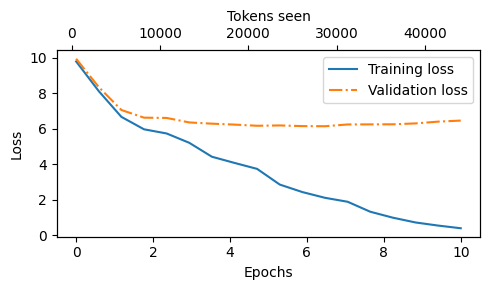

In [31]:
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
def to_cpu(x):
    # torch tensor
    if torch.is_tensor(x):
        return x.detach().cpu()
    # list of tensors
    if isinstance(x, (list, tuple)) and len(x) > 0 and torch.is_tensor(x[0]):
        return torch.stack([t.detach().cpu() for t in x])
    return x

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    epochs_seen  = np.asarray(to_cpu(epochs_seen))
    tokens_seen  = np.asarray(to_cpu(tokens_seen))
    train_losses = np.asarray(to_cpu(train_losses))
    val_losses   = np.asarray(to_cpu(val_losses))

    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.savefig("loss-plot.pdf")
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Inference and Text Generation

After training, the model is used for **inference** to generate new text.

A prompt is provided as input, and the model predicts the **next tokens sequentially** using the learned language patterns.  
The generated token IDs are then decoded back into readable text.

In [32]:
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_simple_text(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


## Token Sampling and Temperature Scaling

This section demonstrates how language models select the **next token during text generation**.

- **Softmax** converts logits into probabilities over the vocabulary.
- **Greedy decoding** selects the token with the highest probability.
- **Sampling** introduces randomness by drawing tokens from the probability distribution.
- **Temperature scaling** controls randomness:
  - Lower temperature → more deterministic predictions
  - Higher temperature → more diverse and creative outputs

These techniques influence the style and variability of generated text.

In [33]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits,dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [34]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [35]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


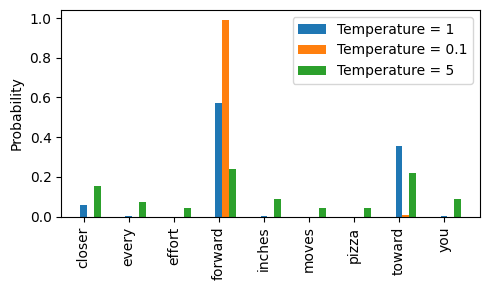

In [36]:
def softmax_with_temperature(logits,temperature):
    scaled_logits = logits/temperature
    return torch.softmax(scaled_logits,dim=0)

temperatures = [1,0.1,5]

# Plotting
x = torch.arange(len(vocab))
scaled_probas = [softmax_with_temperature(next_token_logits,T) for T in temperatures]
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

In [22]:
temperatures = [1,0.0001,5]
scaled_probas = [softmax_with_temperature(next_token_logits,T) for T in temperatures]
count = 0
for scaled_prob in scaled_probas:
    print(f"Temperature: {temperatures[count]}")
    print_sampled_tokens(scaled_prob)
    print("\n")
    count += 1

Temperature: 1
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


Temperature: 0.0001
0 x closer
0 x every
0 x effort
1000 x forward
0 x inches
0 x moves
0 x pizza
0 x toward
0 x you


Temperature: 5
165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you




## Top-K Sampling for Token Selection

This section demonstrates **Top-K sampling**, a common decoding strategy used in language models.

Instead of considering the entire vocabulary, the model selects only the **top K tokens with the highest logits** and masks the rest.  
Softmax is then applied to this filtered set to compute probabilities.

Benefits of Top-K sampling:

- Reduces low-probability noise
- Improves generation quality
- Maintains controlled diversity in generated text

In [23]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

In [24]:
top_k = 3
top_logits,top_pos = torch.topk(next_token_logits,top_k)
print("Top Logits", top_logits)
print("Top Positions", top_pos)

Top Logits tensor([6.7500, 6.2800, 4.5100])
Top Positions tensor([3, 7, 0])


In [25]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits                         
    )

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [26]:
tok_k_probas = torch.softmax(new_logits,dim=0)
print(tok_k_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


## Advanced Text Generation

This function extends the basic generation process with additional decoding strategies.

Features included:

- **Temperature Scaling** – controls randomness in token sampling  
- **Top-K Sampling** – restricts predictions to the most probable tokens  
- **Greedy Decoding** – selects the highest probability token when temperature is 0  
- **End-of-Sequence Handling** – stops generation when a specified EOS token appears

These techniques help balance **coherence and diversity** in generated text.

In [27]:
def generate(model,idx,max_new_tokens,context_size,temperature=0.0,top_k=None,eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:,-context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:,-1,:]

        if top_k is not None:
            top_logits,_ = torch.topk(logits,top_k)
            min_val = top_logits[:,-1]
            logits = torch.where(
                condition=logits < min_val,
                input=torch.tensor(float("-inf")).to(logits.device),
                other=logits
            )
        
        if temperature > 0.0:
            logits = logits/temperature
            probs = torch.softmax(logits,dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits,dim=-1,keepdim=True)

        if idx_next == eos_id:
            break
        idx = torch.cat((idx,idx_next),dim=1)

    return idx

## Final Text Generation Example

In this step, the trained GPT model generates text from an input prompt.

The generation process uses:

- **Top-K filtering** to restrict predictions to the most likely tokens  
- **Greedy decoding (temperature = 0)** for deterministic output  

The resulting token sequence is decoded back into natural language text.

In [28]:
torch.manual_seed(123)
token_ids = generate(model=model,
                     idx=text_to_token_ids("Every Effort moves you",tokenizer=tokenizer),
                     max_new_tokens=15,
                     context_size=GPT_CONFIG_124M["context_length"],
                     temperature=0.0,
                     top_k=200
                     )

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every Effort moves you know; and in spite of, his pictures--so handsome, so charming


## Model Checkpoint Saving

After training, the model and optimizer states are saved as a checkpoint.

Saving checkpoints allows the model to be **reloaded later for inference, further training, or experimentation** without retraining from scratch.

In [29]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    },"model_and_optimizer.pth"
)